# ALE (Accumulated Local Effects) Plots

ALE plots show the average effect of a feature on the prediction, correcting for feature correlations — unlike PDP (Partial Dependence Plots) which can produce misleading results when features are correlated. ALE plots compute effects within small windows of the feature space, making them unbiased and robust to realistic data distributions.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from PyALE import ale

In [3]:
# Load California Housing dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train RandomForestRegressor
rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Evaluate
train_score = rf.score(X_train, y_train)
test_score = rf.score(X_test, y_test)
print(f"Train R²: {train_score:.3f}")
print(f"Test R²: {test_score:.3f}")

Train R²: 0.972
Test R²: 0.804


PyALE._ALE_generic:INFO: Continuous feature detected.


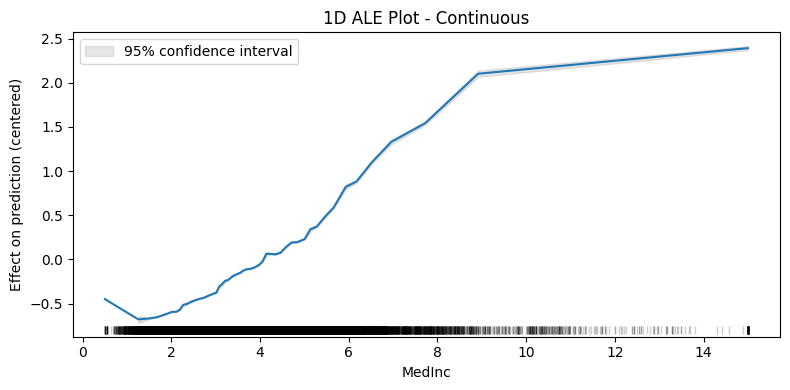

In [4]:
# ALE plot for MedInc (Median Income) feature
ale(X=X_train, model=rf, feature=['MedInc'], grid_size=50)
plt.tight_layout()
plt.show()

PyALE._ALE_generic:INFO: Continuous feature detected.


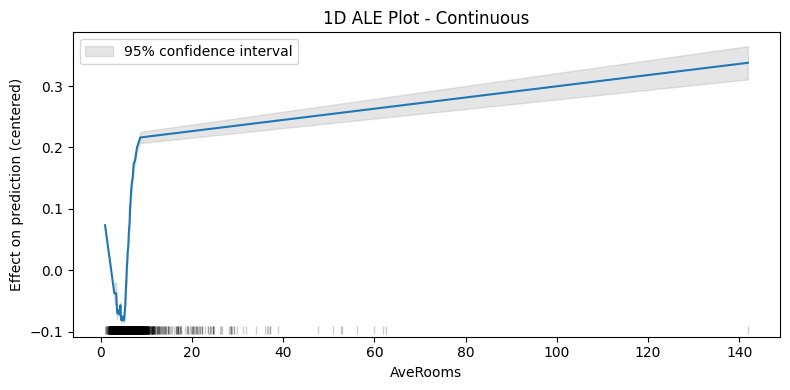

In [5]:
# ALE plot for AveRooms feature
ale(X=X_train, model=rf, feature=['AveRooms'], grid_size=50)
plt.tight_layout()
plt.show()

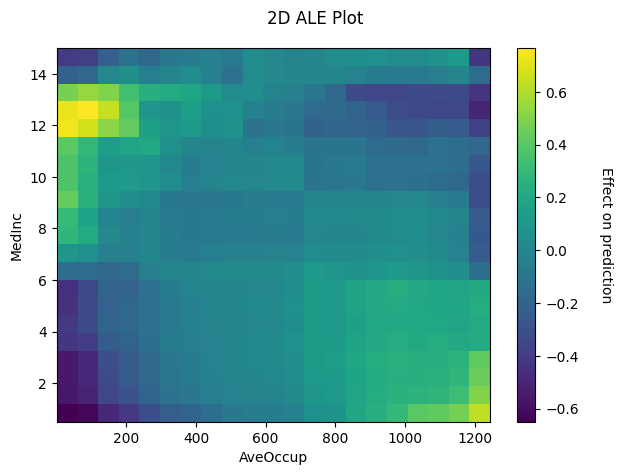

In [6]:
# 2D ALE plot for feature interaction
ale(X=X_train, model=rf, feature=['MedInc', 'AveOccup'], grid_size=20)
plt.tight_layout()
plt.show()

## ALE vs PDP

Unlike Partial Dependence Plots (PDP), ALE plots do not create unrealistic data combinations from correlated features. For example, ALE won't combine high median income (MedInc) with very low average rooms (AveRooms) if that combination rarely or never occurs in the data. This makes ALE far more reliable for understanding how features actually drive predictions in realistic datasets.